# Checkpoints Inspection (MLM/NSP + Attention Hooks)

학습 중 저장된 체크포인트(`checkpoint_step_*.pth`)를 로드해서,
- `metrics.csv`로 학습 진행 확인
- 입력 문장으로 MLM/NSP 예측 확인
- attention을 hook으로 추출해 heatmap으로 시각화
까지 수행합니다.


In [1]:
import re
import csv
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

REPO_ROOT = Path(".").resolve()
# 노트북 실행 cwd가 repo 루트가 아닐 수 있으므로, 상위로 올라가며 `runs/`를 찾습니다.
while not (REPO_ROOT / "runs").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "runs").exists(), f"Could not locate repo root with `runs/`. cwd={Path('.').resolve()}"
SRC_ROOT = (REPO_ROOT / "src").resolve()
BERT_DIR = (SRC_ROOT / "model").resolve()

import sys
# `src/model`에는 __init__.py가 없을 수 있어서, 패키지 import 대신 파일 폴더를 sys.path에 추가합니다.
if str(BERT_DIR) not in sys.path:
    sys.path.insert(0, str(BERT_DIR))

from bert import BERT, BERTLM
from transformers import BertTokenizerFast

RUN_DIR = REPO_ROOT / "runs" / "L12_H1024_A16_seed42"
assert RUN_DIR.exists(), f"RUN_DIR not found: {RUN_DIR}"

CKPT_STEPS = sorted(
    [
        int(m.group(1))
        for p in RUN_DIR.glob("checkpoint_step_*.pth")
        for m in [re.search(r"checkpoint_step_(\\d+)\\.pth$", p.name)]
        if m is not None
    ]
)
CKPT_STEPS


/home/ssai/anaconda3/envs/bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[]

Loaded 100 metric rows from metrics.csv
Last row: {'step': '1000000', 'epoch': '1', 'lr': '0.0', 'train_loss': '2.1364858150482178', 'mlm_loss': '2.0547397136688232', 'nsp_loss': '0.08174614608287811', 'train_mlm_acc': '0.5968063872255489', 'train_nsp_acc': '0.96875', 'step_time': '0.11824358580633998', 'gpu_mem_gb': '3.2405881881713867'}


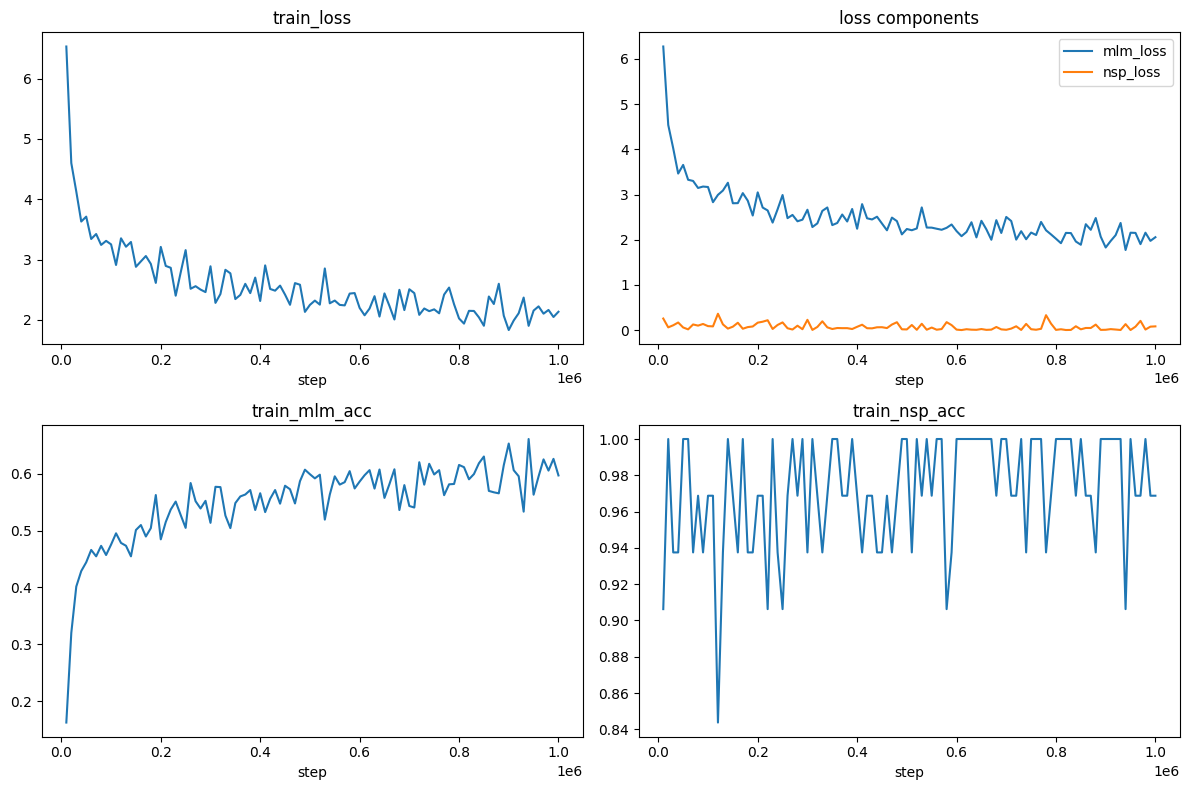

In [2]:
metrics_path = RUN_DIR / "metrics.csv"
assert metrics_path.exists(), f"metrics.csv not found: {metrics_path}"

rows = []
with metrics_path.open("r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append(r)

print(f"Loaded {len(rows)} metric rows from {metrics_path.name}")
print("Last row:", rows[-1])

steps = [int(r["step"]) for r in rows]
train_loss = [float(r["train_loss"]) for r in rows]
mlm_loss = [float(r["mlm_loss"]) for r in rows]
nsp_loss = [float(r["nsp_loss"]) for r in rows]
train_mlm_acc = [float(r["train_mlm_acc"]) for r in rows]
train_nsp_acc = [float(r["train_nsp_acc"]) for r in rows]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
axes[0].plot(steps, train_loss)
axes[0].set_title("train_loss")
axes[1].plot(steps, mlm_loss, label="mlm_loss")
axes[1].plot(steps, nsp_loss, label="nsp_loss")
axes[1].set_title("loss components")
axes[1].legend()
axes[2].plot(steps, train_mlm_acc)
axes[2].set_title("train_mlm_acc")
axes[3].plot(steps, train_nsp_acc)
axes[3].set_title("train_nsp_acc")
for ax in axes:
    ax.set_xlabel("step")
plt.tight_layout()
plt.show()


In [3]:
CKPT_STEP = 1000000  # change if you want (e.g. 100000, 200000, 300000)
# assert CKPT_STEP in CKPT_STEPS, f"CKPT_STEP not found. Available: {CKPT_STEPS}"

ckpt_path = RUN_DIR / f"checkpoint_step_{CKPT_STEP}.pth"
ckpt_path


PosixPath('/home/ssai/Workspace/BERT_repo/runs/L12_H1024_A16_seed42/checkpoint_step_1000000.pth')

In [5]:
def get_metrics_for_step(step: int):
    with metrics_path.open("r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            if int(r["step"]) == int(step):
                return r
    return None

print("metrics at checkpoint step:", get_metrics_for_step(CKPT_STEP))

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
if tokenizer.pad_token_id != 0:
    raise ValueError(f"Expected pad_token_id=0, got {tokenizer.pad_token_id}")

vocab_size = tokenizer.vocab_size
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"

model = BERTLM(BERT(vocab_size=vocab_size)).to(device)
model.eval()

ckpt = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(ckpt["model_state_dict"], strict=True)
print(f"Loaded checkpoint: {ckpt_path.name} on device: {device}")


metrics at checkpoint step: {'step': '1000000', 'epoch': '1', 'lr': '0.0', 'train_loss': '2.1364858150482178', 'mlm_loss': '2.0547397136688232', 'nsp_loss': '0.08174614608287811', 'train_mlm_acc': '0.5968063872255489', 'train_nsp_acc': '0.96875', 'step_time': '0.11824358580633998', 'gpu_mem_gb': '3.2405881881713867'}


RuntimeError: Error(s) in loading state_dict for BERTLM:
	size mismatch for bert.inputEmbedding.token.embedding.weight: copying a param with shape torch.Size([30522, 1024]) from checkpoint, the shape in current model is torch.Size([30522, 768]).
	size mismatch for bert.inputEmbedding.position.pos_embedding: copying a param with shape torch.Size([1, 512, 1024]) from checkpoint, the shape in current model is torch.Size([1, 512, 768]).
	size mismatch for bert.inputEmbedding.segment.embedding.weight: copying a param with shape torch.Size([2, 1024]) from checkpoint, the shape in current model is torch.Size([2, 768]).
	size mismatch for bert.inputEmbedding.layer_norm.gamma: copying a param with shape torch.Size([1024]) from checkpoint, the shape in current model is torch.Size([768]).
	size mismatch for bert.inputEmbedding.layer_norm.beta: copying a param with shape torch.Size([1024]) from checkpoint, the shape in current model is torch.Size([768]).
	size mismatch for bert.encoder_blocks.0.at

## NSP sanity check (라벨/구현 이상 탐지)

- A: 랜덤 초기화 모델에서 `true nsp_label`의 loss가 `~ln(2)=0.693` 근처인지 확인
- B: 학습 모델에서 `nsp_label`을 셔플하면 loss가 유의미하게 올라가는지 확인

이 두 조건이 동시에 맞으면, 현재 `nsp_loss`가 낮아 보이는 현상이 상대적으로 신뢰할만합니다.

In [5]:
from datasets import load_from_disk

DATASET_DIR = REPO_ROOT / "data" / "pretraining_instances_spmask"
assert DATASET_DIR.exists(), f"dataset dir not found: {DATASET_DIR}"

# 작은 샘플로 sanity check만 수행합니다.
N = 32
ds = load_from_disk(str(DATASET_DIR))
N = min(N, len(ds))
batch = ds.select(range(N))

input_ids = torch.tensor(batch["input_ids"], dtype=torch.long)
token_type_ids = torch.tensor(batch["token_type_ids"], dtype=torch.long)
nsp_labels_true = torch.tensor(batch["nsp_label"], dtype=torch.long)

input_ids = input_ids.to(device)
token_type_ids = token_type_ids.to(device)
nsp_labels_true = nsp_labels_true.to(device)

# Same shuffle order for both models
perm = torch.randperm(N)
nsp_labels_shuf = nsp_labels_true[perm]

criterion_nsp = torch.nn.CrossEntropyLoss()

# (B) 학습 모델: true label vs shuffled label
pred_nsp_logits, _ = model(input_ids, token_type_ids)
loss_nsp_true = float(criterion_nsp(pred_nsp_logits, nsp_labels_true).item())
loss_nsp_shuf = float(criterion_nsp(pred_nsp_logits, nsp_labels_shuf).item())

# (A) 랜덤 초기화 모델: true label에서의 loss (기대값 ~ 0.693)
model_rand = BERTLM(BERT(vocab_size=vocab_size))
model_rand = model_rand.to(device)
model_rand.eval()

pred_nsp_logits_rand, _ = model_rand(input_ids, token_type_ids)
loss_rand_true = float(criterion_nsp(pred_nsp_logits_rand, nsp_labels_true).item())
loss_rand_shuf = float(criterion_nsp(pred_nsp_logits_rand, nsp_labels_shuf).item())

print(f"[Trained] NSP loss (true labels):      {loss_nsp_true:.4f}")
print(f"[Trained] NSP loss (shuffled labels):  {loss_nsp_shuf:.4f}")
print(f"[Random ] NSP loss (true labels):      {loss_rand_true:.4f}  (expect ~0.693)")
print(f"[Random ] NSP loss (shuffled labels):  {loss_rand_shuf:.4f}")

# Heuristic: shuffled loss가 true loss보다 유의미하게 커지면 라벨/로깅이 정상일 가능성이 큼
print("Heuristic: shuffled_loss - true_loss (trained)=", loss_nsp_shuf - loss_nsp_true)


OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 23.53 GiB of which 60.50 MiB is free. Process 2083356 has 8.30 GiB memory in use. Process 4063488 has 11.03 GiB memory in use. Including non-PyTorch memory, this process has 4.10 GiB memory in use. Of the allocated memory 3.64 GiB is allocated by PyTorch, and 20.42 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [6]:
@torch.no_grad()
def tokenize_pair(sent_a: str, sent_b: str, max_length: int = 64):
    tok = tokenizer(
        sent_a,
        sent_b,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    return tok["input_ids"], tok["token_type_ids"], tok["attention_mask"]


@torch.no_grad()
def predict_nsp(sent_a: str, sent_b: str, max_length: int = 64):
    input_ids, token_type_ids, attention_mask = tokenize_pair(sent_a, sent_b, max_length=max_length)
    input_ids = input_ids.to(device)
    token_type_ids = token_type_ids.to(device)

    pred_nsp_logits, _ = model(input_ids, token_type_ids)
    probs = F.softmax(pred_nsp_logits, dim=-1)[0].detach().cpu().tolist()
    # Dataset convention: class 0=is_next, class 1=not_next
    return {
        "probs_is_next": probs[0],
        "probs_not_next": probs[1],
        "logits": pred_nsp_logits[0].detach().cpu().tolist(),
        "attention_mask": attention_mask[0].detach().cpu(),
        "input_ids": input_ids[0].detach().cpu(),
    }


@torch.no_grad()
def pick_mask_position(text: str, max_length: int = 64):
    tok = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    input_ids = tok["input_ids"][0]

    pad_id = tokenizer.pad_token_id
    special_mask = torch.tensor(
        tokenizer.get_special_tokens_mask(input_ids.tolist(), already_has_special_tokens=True),
        dtype=torch.bool,
    )

    candidates = torch.where((~special_mask) & (input_ids != pad_id))[0]
    if len(candidates) == 0:
        raise RuntimeError("No valid token positions to mask.")

    # Strategy: mask the first non-special token.
    return tok, int(candidates[0].item())


@torch.no_grad()
def predict_mlm(text: str, max_length: int = 64, topk: int = 10):
    tok, pos = pick_mask_position(text, max_length=max_length)
    input_ids = tok["input_ids"].to(device)
    token_type_ids = tok["token_type_ids"].to(device)

    masked_input_ids = input_ids.clone()
    original_id = int(masked_input_ids[0, pos].item())
    masked_input_ids[0, pos] = tokenizer.mask_token_id

    _, pred_mlm_logits = model(masked_input_ids, token_type_ids)
    logits = pred_mlm_logits[0, pos]  # [vocab]

    topv, topi = torch.topk(logits, k=topk, dim=-1)
    top_tokens = [tokenizer.convert_ids_to_tokens(int(i)) for i in topi.tolist()]
    top_scores = [float(v) for v in topv.tolist()]

    return {
        "masked_position": pos,
        "original_token": tokenizer.convert_ids_to_tokens(original_id),
        "top_tokens": top_tokens,
        "top_scores": top_scores,
    }


def register_attention_hooks(model_: torch.nn.Module):
    """Capture p_attn from each transformer layer's Attention module.

    Each layer's Attention.forward returns (context, p_attn).
    """
    attn_maps = {}  # layer_idx -> [batch, heads, seq, seq] on CPU
    handles = []

    for layer_idx, block in enumerate(model_.bert.encoder_blocks):
        attn_module = block.attention.attention

        def make_hook(li: int):
            def hook(module, inputs, output):
                if isinstance(output, tuple) and len(output) == 2:
                    attn_maps[li] = output[1].detach().cpu()
            return hook

        handles.append(attn_module.register_forward_hook(make_hook(layer_idx)))

    return attn_maps, handles


@torch.no_grad()
def attention_matrix_from_nsp(sent_a: str, sent_b: str, max_length: int = 64, layer: int = 11, head: int = 0):
    input_ids, token_type_ids, attention_mask = tokenize_pair(sent_a, sent_b, max_length=max_length)
    input_ids = input_ids.to(device)
    token_type_ids = token_type_ids.to(device)

    attn_maps, handles = register_attention_hooks(model)
    try:
        model(input_ids, token_type_ids)
    finally:
        for h in handles:
            h.remove()

    if layer not in attn_maps:
        raise RuntimeError(f"No attention map captured for layer={layer}")

    p_attn = attn_maps[layer][0, head]  # [seq, seq]
    seq_len = int(attention_mask[0].sum().item())
    p_attn = p_attn[:seq_len, :seq_len]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0, :seq_len].detach().cpu().tolist())
    return p_attn.numpy(), tokens


아래에서 예시 문장쌍으로 NSP 확률, 단일 문장으로 MLM top-k를 확인합니다.

In [7]:
examples = [
    ("the man went to the store", "he bought some milk"),
    ("the man went to the store", "the sky is blue"),
]

for a, b in examples:
    res = predict_nsp(a, b, max_length=64)
    print("---")
    print("A:", a)
    print("B:", b)
    print("probs_is_next:", res["probs_is_next"])
    print("probs_not_next:", res["probs_not_next"])

mlm_texts = [
    "the man went to the store and bought some milk",
    "the sky is blue and the sun is bright",
]

for t in mlm_texts:
    mlm_res = predict_mlm(t, max_length=64, topk=8)
    print("---")
    print("Text:", t)
    print("Masked position:", mlm_res["masked_position"])
    print("Original token:", mlm_res["original_token"])
    print("Top tokens:", mlm_res["top_tokens"])
    print("Top scores:", [round(x, 3) for x in mlm_res["top_scores"]])


---
A: the man went to the store
B: he bought some milk
probs_is_next: 0.34652528166770935
probs_not_next: 0.653474748134613
---
A: the man went to the store
B: the sky is blue
probs_is_next: 0.3565971255302429
probs_not_next: 0.6434028744697571
---
Text: the man went to the store and bought some milk
Masked position: 1
Original token: the
Top tokens: ['##bana', 'enrolled', '##ram', 'ma', 'tara', 'romance', 'reed', '##hman']
Top scores: [2.014, 1.979, 1.925, 1.916, 1.873, 1.869, 1.849, 1.844]
---
Text: the sky is blue and the sun is bright
Masked position: 1
Original token: the
Top tokens: ['enrolled', '##bana', 'ma', '##ram', 'continued', 'nature', 'wing', 'stratford']
Top scores: [2.132, 2.096, 2.044, 1.941, 1.888, 1.876, 1.845, 1.792]


In [15]:
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
from transformers import BertTokenizerFast

# repo root 자동 탐색
REPO_ROOT = Path('.').resolve()
while not (REPO_ROOT / 'runs').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'runs').exists(), f"runs/를 찾지 못했습니다. cwd={Path('.').resolve()}"

SRC_ROOT = REPO_ROOT / 'src'
BERT_DIR = SRC_ROOT / 'model'
if str(BERT_DIR) not in sys.path:
    sys.path.insert(0, str(BERT_DIR))

from bert import BERT, BERTLM

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

RUN_DIR = REPO_ROOT / 'runs' / 'L12_H768_A12_seed42'
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
if tokenizer.pad_token_id != 0:
    raise ValueError(f"Expected pad_token_id=0, got {tokenizer.pad_token_id}")


def load_model(ckpt_path):
    vocab_size = tokenizer.vocab_size
    model = BERTLM(BERT(vocab_size=vocab_size))
    ckpt = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'], strict=True)
    model.to(DEVICE)
    model.eval()
    return model


def predict_mlm(model, text, topk=8, max_length=64):
    tok = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
    )
    input_ids = tok['input_ids'].to(DEVICE)
    token_type_ids = tok.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(input_ids)
    token_type_ids = token_type_ids.to(DEVICE)

    mask_positions = (input_ids[0] == tokenizer.mask_token_id).nonzero(as_tuple=False).view(-1)
    assert len(mask_positions) > 0, "[MASK] 토큰이 필요합니다"

    with torch.no_grad():
        _, mlm_logits = model(input_ids, token_type_ids)

    results = []
    for pos in mask_positions.tolist():
        logits = mlm_logits[0, pos]
        topk_ids = logits.topk(topk).indices.tolist()
        topk_tokens = [tokenizer.convert_ids_to_tokens(i) for i in topk_ids]
        topk_scores = [float(x) for x in logits[topk_ids].tolist()]
        results.append((topk_tokens, topk_scores))
    return results


def predict_nsp(model, sent_a, sent_b, max_length=64):
    tok = tokenizer(
        sent_a,
        sent_b,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
    )
    input_ids = tok['input_ids'].to(DEVICE)
    token_type_ids = tok.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(input_ids)
    token_type_ids = token_type_ids.to(DEVICE)

    with torch.no_grad():
        nsp_logits, _ = model(input_ids, token_type_ids)

    probs = F.softmax(nsp_logits, dim=-1)[0]
    return probs[0].item(), probs[1].item()  # is_next, not_next


mlm_texts = [
    'the man went to the [MASK] to buy food',
    'he drank a cup of [MASK]',
    'paris is the capital of [MASK]',
    'the cat sat on the [MASK]',
    'he [MASK] to school yesterday',
]

nsp_examples = [
    ('the man went to the store', 'he bought some milk'),
    ('the man went to the store', 'quantum physics is difficult'),
]


def evaluate_checkpoint(ckpt_path):
    print(f"\n================ {ckpt_path.name} ================\n")
    model = load_model(ckpt_path)

    print('MLM TEST')
    for text in mlm_texts:
        res = predict_mlm(model, text)
        print('\nText:', text)
        for tokens, scores in res:
            print('Top tokens:', tokens)
            print('Top scores:', [round(s, 3) for s in scores])

    print('\nNSP TEST')
    for a, b in nsp_examples:
        is_next, not_next = predict_nsp(model, a, b)
        print('\nA:', a)
        print('B:', b)
        print('is_next:', round(is_next, 4))
        print('not_next:', round(not_next, 4))


checkpoints = [
    RUN_DIR / 'checkpoint_step_1000000.pth',
]

for ckpt in checkpoints:
    if ckpt.exists():
        evaluate_checkpoint(ckpt)
    else:
        print(f'[skip] not found: {ckpt}')



================ checkpoint_step_1000000.pth ================



RuntimeError: Error(s) in loading state_dict for BERTLM:
	size mismatch for bert.inputEmbedding.token.embedding.weight: copying a param with shape torch.Size([30522, 768]) from checkpoint, the shape in current model is torch.Size([30522, 1024]).
	size mismatch for bert.inputEmbedding.position.pos_embedding: copying a param with shape torch.Size([1, 512, 768]) from checkpoint, the shape in current model is torch.Size([1, 512, 1024]).
	size mismatch for bert.inputEmbedding.segment.embedding.weight: copying a param with shape torch.Size([2, 768]) from checkpoint, the shape in current model is torch.Size([2, 1024]).
	size mismatch for bert.inputEmbedding.layer_norm.gamma: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for bert.inputEmbedding.layer_norm.beta: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for bert.encoder_blocks.0.at

In [13]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F

# 현재 cwd가 repo root가 아닐 수도 있으니 runs/가 있는 상위 디렉토리를 찾습니다.
REPO_ROOT = Path('.').resolve()
while not (REPO_ROOT / 'runs').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

SRC_ROOT = REPO_ROOT / 'src'
BERT_DIR = SRC_ROOT / 'model'
if str(BERT_DIR) not in sys.path:
    sys.path.insert(0, str(BERT_DIR))

from bert import BERT, BERTLM  # src/model/bert.py
from transformers import BertTokenizerFast

RUN_DIR = REPO_ROOT / 'runs' / 'L12_H768_A12_seed42'

# 사용자가 원하는 체크포인트 스텝을 고르세요.
CKPT_STEP = 400000
ckpt_path = RUN_DIR / f'checkpoint_step_{CKPT_STEP}.pth'
assert ckpt_path.exists(), f'checkpoint not found: {ckpt_path}'

# device 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
if tokenizer.pad_token_id != 0:
    raise ValueError(f"Expected tokenizer.pad_token_id=0, got {tokenizer.pad_token_id}")

vocab_size = tokenizer.vocab_size

# model
model = BERTLM(BERT(vocab_size=vocab_size))
ckpt = torch.load(ckpt_path, map_location='cpu')
model.load_state_dict(ckpt['model_state_dict'], strict=True)
model.to(device)
model.eval()


@torch.no_grad()
def predict_mlm_one_mask(text_with_mask: str, max_length: int = 64, topk: int = 8):
    """입력 text에 '[MASK]'가 포함되어 있다고 가정하고, 해당 마스크 위치 top-k를 반환합니다."""

    tok = tokenizer(
        text_with_mask,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
    )
    input_ids = tok['input_ids'].to(device)
    token_type_ids = tok.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(input_ids)
    token_type_ids = token_type_ids.to(device)

    mask_positions = (input_ids[0] == tokenizer.mask_token_id).nonzero(as_tuple=False).view(-1)
    if len(mask_positions) == 0:
        raise ValueError("입력에 '[MASK]'가 포함되어 있어야 합니다.")

    # 여러 개면 첫 번째만
    pos = int(mask_positions[0].item())

    _, pred_mlm_logits = model(input_ids, token_type_ids)
    logits = pred_mlm_logits[0, pos]  # [vocab]

    topv, topi = torch.topk(logits, k=topk, dim=-1)
    top_tokens = [tokenizer.convert_ids_to_tokens(int(i)) for i in topi.tolist()]
    top_scores = [float(v) for v in topv.tolist()]

    # 가시화용: 토큰 시퀀스(패딩 제외)
    attn_mask = tok.get('attention_mask')
    if attn_mask is None:
        seq_len = (input_ids[0] != 0).sum().item()
    else:
        seq_len = int(attn_mask[0].sum().item())

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0, :seq_len].detach().cpu().tolist())

    return {
        'pos': pos,
        'tokens': tokens,
        'top_tokens': top_tokens,
        'top_scores': top_scores,
    }


@torch.no_grad()
def predict_nsp(sent_a: str, sent_b: str, max_length: int = 64):
    tok = tokenizer(
        sent_a,
        sent_b,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
    )
    input_ids = tok['input_ids'].to(device)
    token_type_ids = tok.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(input_ids)
    token_type_ids = token_type_ids.to(device)

    pred_nsp_logits, _ = model(input_ids, token_type_ids)
    probs = F.softmax(pred_nsp_logits, dim=-1)[0].detach().cpu().tolist()
    # dataset convention: class 0 = is_next, class 1 = not_next
    return {
        'probs_is_next': float(probs[0]),
        'probs_not_next': float(probs[1]),
        'logits': [float(x) for x in pred_nsp_logits[0].detach().cpu().tolist()],
    }


print(f"Loaded checkpoint: {ckpt_path.name} | device={device}")

# =========================
# Quick tests
# =========================
mlm_texts = [
    "the man went to the [MASK] to buy food",
    "he drank a cup of [MASK]",
    "paris is the capital of [MASK]",
]

nsp_examples = [
    ("the man went to the store", "he bought some milk"),
    ("the man went to the store", "quantum physics is difficult"),
]

print("\n🔥 MLM TEST")
for t in mlm_texts:
    res = predict_mlm_one_mask(t, max_length=64, topk=8)
    print("- Text:", t)
    print("  mask_pos:", res['pos'])
    print("  Top tokens:", res['top_tokens'])
    print("  Top scores:", [round(x, 4) for x in res['top_scores']])

print("\n🔥 NSP TEST")
for a, b in nsp_examples:
    res = predict_nsp(a, b, max_length=64)
    print("- A:", a)
    print("  B:", b)
    print("  is_next:", round(res['probs_is_next'], 4), "not_next:", round(res['probs_not_next'], 4))


RuntimeError: Error(s) in loading state_dict for BERTLM:
	size mismatch for bert.inputEmbedding.token.embedding.weight: copying a param with shape torch.Size([30522, 768]) from checkpoint, the shape in current model is torch.Size([30522, 1024]).
	size mismatch for bert.inputEmbedding.position.pos_embedding: copying a param with shape torch.Size([1, 512, 768]) from checkpoint, the shape in current model is torch.Size([1, 512, 1024]).
	size mismatch for bert.inputEmbedding.segment.embedding.weight: copying a param with shape torch.Size([2, 768]) from checkpoint, the shape in current model is torch.Size([2, 1024]).
	size mismatch for bert.inputEmbedding.layer_norm.gamma: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for bert.inputEmbedding.layer_norm.beta: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for bert.encoder_blocks.0.at

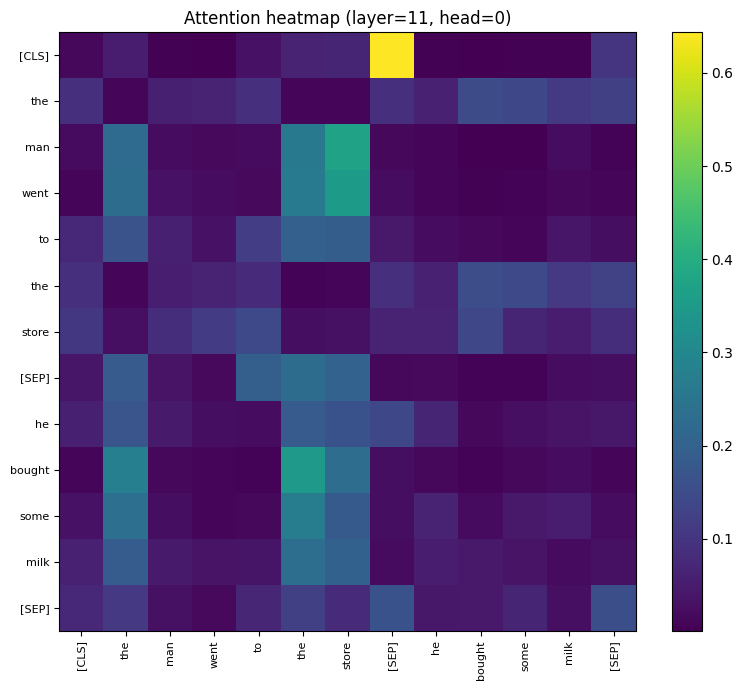

In [13]:
# Attention heatmap (NSP forward)
sent_a, sent_b = examples[0]

layer = 11  # 0..11
head = 0    # 0..11

attn_mat, tokens = attention_matrix_from_nsp(sent_a, sent_b, max_length=64, layer=layer, head=head)

plt.figure(figsize=(8, 7))
plt.imshow(attn_mat, aspect="auto", cmap="viridis")
plt.colorbar()
plt.title(f"Attention heatmap (layer={layer}, head={head})")

# Label only a subset to keep it readable
show_every = max(1, len(tokens) // 20)
tick_positions = list(range(0, len(tokens), show_every))
tick_labels = [tokens[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=8)
plt.yticks(tick_positions, tick_labels, fontsize=8)

plt.tight_layout()
plt.show()
